# Pseudospectral Methods, Part X: Dubins Drone Search — Pareto Frontier of Detection vs Time

Part IX let the drone slow down anywhere, even to a near-stop over a target's mode. Real flight
vehicles can't. Fixed-wing UAVs, missiles, and most autonomous aircraft fly at roughly **constant
forward speed** with a **bounded turning rate**. This is the **Dubins vehicle** model — the
canonical kinematic abstraction for fixed-wing flight, named after L. E. Dubins's 1957 paper on
shortest paths between oriented configurations.

The Dubins constraint changes the search problem qualitatively:

* The drone **can't slow down** to dwell over a target. To linger, it must **fly a loiter
  circle** of radius $\ge R_\mathrm{min}$.
* Total path length is exactly $V\,T$ — fixing $T$ fixes path length. The optimization becomes
  *what shape* gives the most detection for a given length.
* Detection is purely a function of trajectory geometry: pass closer to high-prior areas, get
  more exposure. Loiter circles around target modes accumulate exposure but cost time.

We make this a **multi-objective** problem with weighted-sum cost

$$
J(\boldsymbol\rho_\mathrm{traj}, T) \;=\; -\mathbb{E}[\#\mathrm{found}] \;+\; \alpha\,T
$$

where $\alpha \ge 0$ is the **time penalty**. Solving for a sweep of $\alpha$ values traces out
the Pareto frontier in $(T, \mathbb{E}[\#\mathrm{found}])$ space:

* $\alpha$ small → optimizer happily flies loiter circles over each target → long $T$, high $P_\mathrm{detect}$.
* $\alpha$ large → time penalty dominates → drone takes the shortest tour through modes → short $T$, low $P_\mathrm{detect}$.

The Pareto frontier is **monotone increasing and concave** — diminishing returns of detection
per unit time as the drone exhausts the easy targets first.

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.optimize as opt
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]


def cc_weights(N):
    if N == 0:
        return np.array([2.0])
    n = np.arange(N + 1)
    theta = np.pi * n / N
    w = np.zeros(N + 1)
    for k in range(N + 1):
        s = sum(np.cos(2 * j * theta[k]) / (4 * j * j - 1) for j in range(1, N // 2 + 1))
        w[k] = (1.0 - 2.0 * s) * 2.0 / N
    w[0] /= 2.0; w[-1] /= 2.0
    return w

## 1. The Dubins vehicle

State $(x, y, \theta)$: planar position plus heading. Control $u(t)$: turning rate. Dynamics:

$$
\dot x = V\,\cos\theta,\quad \dot y = V\,\sin\theta,\quad \dot\theta = u, \quad |u| \le \omega_\mathrm{max}.
$$

Constant forward speed $V$, turning rate bounded in magnitude. Equivalently, the **minimum
turning radius** is $R_\mathrm{min} = V/\omega_\mathrm{max}$ — the tightest circle the drone
can fly. Inside the bound, you can fly straight (S), turn left at full rate (L), turn right
at full rate (R), or anything between.

### The classical Dubins result

Dubins's 1957 paper proved a beautiful structural result: the **shortest path** between two
oriented configurations $(x_0, y_0, \theta_0)$ and $(x_f, y_f, \theta_f)$ is **always** one of
six canonical types built from arcs and straight segments:

$$
\mathrm{LSL},\;\mathrm{RSR},\;\mathrm{LSR},\;\mathrm{RSL},\;\mathrm{RLR},\;\mathrm{LRL}.
$$

Each path is a sequence of three pieces: two end-arcs (with bounded radius) and a connecting
piece (straight line, or a third arc for the curved-curved-curved cases). The shortest path
admits closed-form formulas — try them all six, take the minimum length. This is **classical
Dubins shortest-path** and it's the foundation of every fixed-wing path planner.

But Dubins shortest-path is *between two oriented points* and **does not address obstacles,
multi-objective costs, or detection-style functionals**. For those, we need **Dubins
trajectory optimization** — the same kinematics but with cost and constraints expressed as an
NLP. That's what we do here.

### Dubins NLP formulation

* **Decision variables**: $(x_i, y_i, \theta_i)$ at LGL nodes for $i = 0, \dots, N$, plus $T$.
  Total $3(N+1) + 1$ variables.
* **Dynamics defects** (equality, $2(N+1)$ equations): $\frac{2}{T}(D x)_i = V \cos\theta_i$,
  $\frac{2}{T}(D y)_i = V \sin\theta_i$.
* **Initial conditions** (equality, 3 equations): $x_0, y_0, \theta_0$ fixed. Final state free.
* **Turning-rate inequality** ($2(N+1)$ inequalities): $\bigl|\frac{2}{T}(D\theta)_i\bigr| \le \omega_\mathrm{max}$.
* **Cost**: $J = -\mathbb{E}[\#\mathrm{found}] + \alpha\,T$.

Note: there's no explicit "speed bound" because $V$ is constant by construction — encoded in
the dynamics defects, not as an inequality. This is *fewer* constraints than Part IX, not more,
even though Dubins is a more restrictive vehicle.

## 2. Setting up the NLP

The objective gradient picks up two new terms relative to Part IX:

* $\partial J/\partial \theta_i = 0$ — the cost doesn't depend on heading directly.
* $\partial J/\partial T = -(1/T)\,\Delta x \Delta y \sum_j F_j e^{-E_j} E_j + \alpha$ — the
  detection benefit of a longer time horizon scales with already-accumulated effort, balanced
  against $\alpha$.

The $T$ derivative formula is interesting: it tells us *where* time is spent productively.
If you double $T$ but mostly redistribute over already-effort-saturated regions ($E_j$ large,
$e^{-E_j} E_j$ small), the marginal return is small. If $T$ extends time over still-unsearched
high-prior regions ($e^{-E_j} \approx 1$, $E_j$ moderate), the marginal return is large. At
the Pareto-optimal point, $\partial J/\partial T = 0$ ⟹ the marginal-detection-rate equals
$\alpha$.

In [2]:
def make_dubins_search(N, x_start, theta_start, V, R_min,
                       F_flat, sx_flat, sy_flat, dxdy,
                       lambda_0, sigma_s, alpha):
    '''Returns objective + jac, equality constraints (dynamics + boundary), and turning-rate
    inequality. Decision variable z has length 3(N+1) + 1: [x, y, theta, T].'''
    D, _ = cheb_asc(N)
    w_cc = cc_weights(N)
    omega_max = V / R_min
    n_state = N + 1

    def unpack(z):
        x = z[:n_state]
        y = z[n_state:2 * n_state]
        theta = z[2 * n_state:3 * n_state]
        T = z[3 * n_state]
        return x, y, theta, T

    def detection_terms(z):
        '''Returns (Lam (N+1, M), E (M,), x, y, T) for use in obj + grad.'''
        x, y, _, T = unpack(z)
        dx = x[:, None] - sx_flat[None, :]
        dy = y[:, None] - sy_flat[None, :]
        Lam = lambda_0 * np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
        E = (T / 2) * (w_cc[:, None] * Lam).sum(axis=0)
        return Lam, E, dx, dy, x, y, T

    def objective(z):
        Lam, E, _, _, _, _, T = detection_terms(z)
        Pfound = dxdy * np.sum(F_flat * (1.0 - np.exp(-E)))
        return -Pfound + alpha * T

    def objective_jac(z):
        Lam, E, dx, dy, x, y, T = detection_terms(z)
        weight = F_flat * np.exp(-E)
        common = (T / 2) * w_cc[:, None] * Lam * weight[None, :]
        dJ_dx = -dxdy * (-1 / sigma_s**2) * (common * dx).sum(axis=1)
        dJ_dy = -dxdy * (-1 / sigma_s**2) * (common * dy).sum(axis=1)
        dJ_dtheta = np.zeros(n_state)
        # dJ/dT = -(1/T) dxdy sum_j F_j exp(-E_j) E_j + alpha
        dJ_dT = -dxdy * np.sum(weight * E) / T + alpha
        return np.concatenate([dJ_dx, dJ_dy, dJ_dtheta, [dJ_dT]])

    def dynamics_eq(z):
        '''(2/T) Dx_i - V cos(theta_i) = 0, similarly for y. Returns (2*(N+1),).'''
        x, y, theta, T = unpack(z)
        defect_x = (2.0 / T) * (D @ x) - V * np.cos(theta)
        defect_y = (2.0 / T) * (D @ y) - V * np.sin(theta)
        return np.concatenate([defect_x, defect_y])

    def boundary_eq(z):
        x, y, theta, _ = unpack(z)
        return np.array([x[0] - x_start[0],
                         y[0] - x_start[1],
                         theta[0] - theta_start])

    def turning_rate_ineq(z):
        '''omega_max - |(2/T) Dtheta_i| >= 0 expressed as two-sided inequality.'''
        _, _, theta, T = unpack(z)
        Dtheta = (2.0 / T) * (D @ theta)
        return np.concatenate([omega_max - Dtheta, omega_max + Dtheta])

    return objective, objective_jac, dynamics_eq, boundary_eq, turning_rate_ineq


def initial_guess_smoothed(N, x_start, theta_start, targets, V, T_guess, w_cc, tau):
    '''TSP greedy waypoint route, then linear interp gives (x, y); heading from forward diff
    smoothed to enforce continuity.'''
    def dist(a, b): return np.sqrt(np.sum((a - b)**2))
    order = []; remaining = list(range(len(targets))); cur = x_start
    while remaining:
        nearest = min(remaining, key=lambda i: dist(cur, targets[i]["mu"]))
        order.append(nearest); cur = targets[nearest]["mu"]; remaining.remove(nearest)
    waypoints = [x_start] + [targets[i]["mu"] for i in order]
    seg_lens = [dist(waypoints[i + 1], waypoints[i]) for i in range(len(waypoints) - 1)]
    total = sum(seg_lens)
    s_cumul = np.array([0.0] + list(np.cumsum(seg_lens)))
    s = (tau + 1) / 2
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    for k in range(N + 1):
        target_s = s[k] * total
        seg = min(np.searchsorted(s_cumul, target_s, side="right") - 1, len(seg_lens) - 1)
        alpha = (target_s - s_cumul[seg]) / max(seg_lens[seg], 1e-9)
        x[k] = waypoints[seg][0] + alpha * (waypoints[seg + 1][0] - waypoints[seg][0])
        y[k] = waypoints[seg][1] + alpha * (waypoints[seg + 1][1] - waypoints[seg][1])
    # Heading from finite difference + smoothing
    dx = np.gradient(x); dy = np.gradient(y)
    theta = np.arctan2(dy, dx)
    # Unwrap to keep continuous
    theta = np.unwrap(theta)
    theta[0] = theta_start
    return np.concatenate([x, y, theta, [T_guess]]), order, total


# Setup (same scenario as Part IX so we can compare)
Lx, Ly = 100.0, 100.0
targets = [
    {"mu": np.array([70.0, 30.0]), "sigma": 8.0, "weight": 1.0},
    {"mu": np.array([40.0, 80.0]), "sigma": 7.0, "weight": 1.0},
    {"mu": np.array([85.0, 65.0]), "sigma": 6.0, "weight": 1.0},
]
x_start_d = np.array([10.0, 10.0])
theta_start_d = np.pi / 4               # heading NE
V = 30.0                                  # constant forward speed
R_min = 5.0                               # minimum turning radius
omega_max = V / R_min                     # = 6 rad/h
sigma_s = 6.0
lambda_0 = 1.0

# Search prior grid
nx, ny = 30, 30
sx_grid = np.linspace(0, Lx, nx); sy_grid = np.linspace(0, Ly, ny)
SX, SY = np.meshgrid(sx_grid, sy_grid)
dxdy = (Lx / (nx - 1)) * (Ly / (ny - 1))
sx_flat, sy_flat = SX.ravel(), SY.ravel()
F_grid = np.zeros_like(SX)
for t in targets:
    F_grid += 1 / (2 * np.pi * t["sigma"]**2) * np.exp(
        -((SX - t["mu"][0])**2 + (SY - t["mu"][1])**2) / (2 * t["sigma"]**2))
F_flat = F_grid.ravel()

# LGL grid
N_d = 40
D_d, tau_d = cheb_asc(N_d)
w_cc_d = cc_weights(N_d)

# Initial guess for medium alpha
T_guess = 7.0
z0_d, order, route_len = initial_guess_smoothed(
    N_d, x_start_d, theta_start_d, targets, V, T_guess, w_cc_d, tau_d
)
print(f"Dubins kinematics: V = {V} km/h, R_min = {R_min} km, omega_max = {omega_max:.3f} rad/h")
print(f"TSP route order: {[chr(65 + k) for k in order]}, length = {route_len:.1f} km")
print(f"Time at constant V over TSP route: {route_len / V:.3f} h (lower bound on feasible T)")
print(f"Initial T guess: {T_guess} h, drone path length budget: {V * T_guess:.1f} km")

Dubins kinematics: V = 30.0 km/h, R_min = 5.0 km, omega_max = 6.000 rad/h
TSP route order: ['A', 'C', 'B'], length = 148.8 km
Time at constant V over TSP route: 4.959 h (lower bound on feasible T)
Initial T guess: 7.0 h, drone path length budget: 210.0 km


## 3. Single solve at $\alpha = 0.05$

Pick a moderate time penalty and solve. With $\alpha = 0.05$ per hour, the drone has to
believe each hour of flight buys $\ge 0.05$ extra detection. In the saturated regime
(high prior already mostly explored) the marginal detection per hour drops below $\alpha$,
and the optimizer terminates the trajectory.

In [3]:
alpha_demo = 0.05
obj_d, jac_d, dyn_d, bd_d, turn_d = make_dubins_search(
    N_d, x_start_d, theta_start_d, V, R_min,
    F_flat, sx_flat, sy_flat, dxdy, lambda_0, sigma_s, alpha_demo,
)

# Verify gradient (just on x and y components — theta part is zero)
g_an = jac_d(z0_d)
g_fd = opt.approx_fprime(z0_d, obj_d, 1e-4)
err = np.max(np.abs(g_an - g_fd)) / max(np.max(np.abs(g_an)), 1e-12)
print(f"Analytic vs FD gradient: max rel err = {err:.2e}")

constraints = [
    {"type": "eq",   "fun": dyn_d},
    {"type": "eq",   "fun": bd_d},
    {"type": "ineq", "fun": turn_d},
]
res_d = opt.minimize(
    obj_d, z0_d, jac=jac_d, method="SLSQP",
    constraints=constraints,
    options={"maxiter": 800, "ftol": 1e-7, "disp": False},
)
print(f"Status: {res_d.message}  ({res_d.nit} iters)")

# Decode result
n_st = N_d + 1
x_d, y_d, th_d, T_d = res_d.x[:n_st], res_d.x[n_st:2*n_st], res_d.x[2*n_st:3*n_st], res_d.x[-1]
Pfound = -res_d.fun + alpha_demo * T_d   # back out P(detect) from J = -P + alpha*T
print(f"alpha = {alpha_demo}:  T* = {T_d:.3f} h,  E[#found] = {Pfound:.3f}")
print(f"Path length = V*T = {V * T_d:.1f} km")

# Check turning rate is respected
om = (2.0 / T_d) * (D_d @ th_d)
print(f"Max |dtheta/dt| at nodes: {np.max(np.abs(om)):.3f}  (omega_max = {omega_max:.3f})")

Analytic vs FD gradient: max rel err = 7.75e-06


Status: Optimization terminated successfully  (752 iters)
alpha = 0.05:  T* = 17.844 h,  E[#found] = 2.074
Path length = V*T = 535.3 km
Max |dtheta/dt| at nodes: 6.000  (omega_max = 6.000)


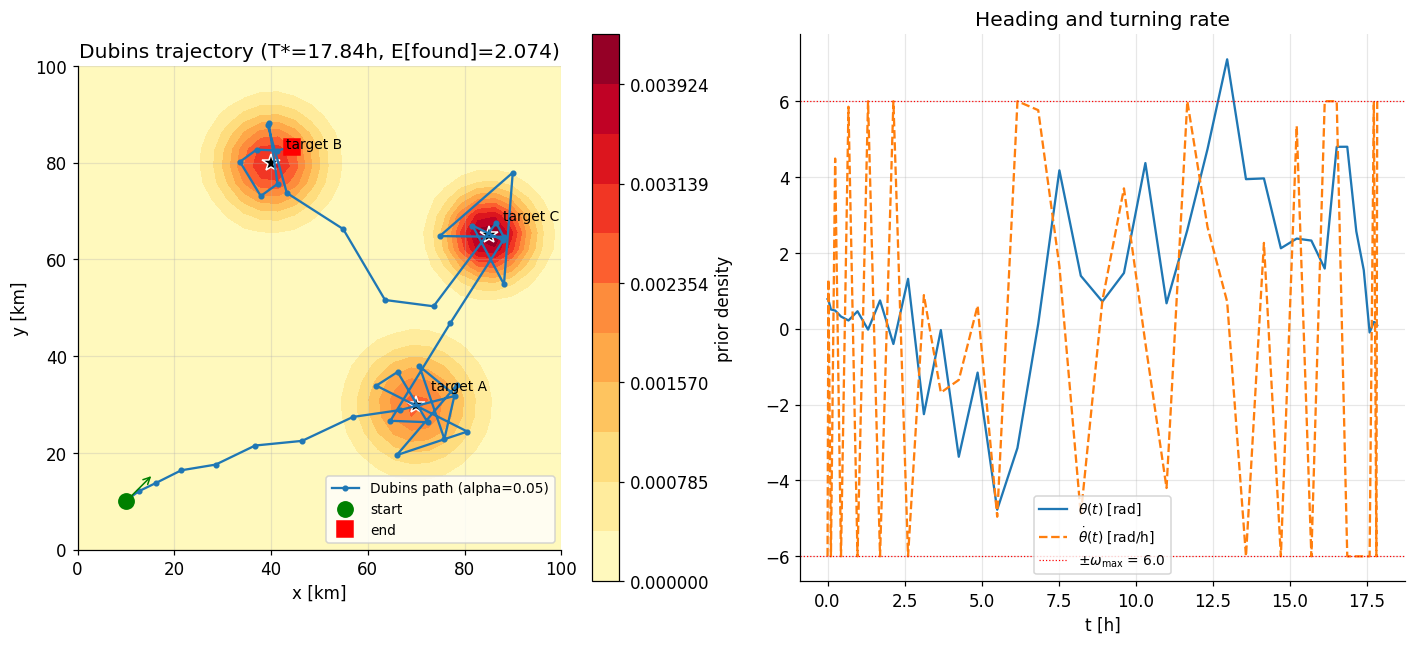

In [4]:
# Plot the Dubins trajectory
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# Prior + trajectory
levels = np.linspace(0, F_grid.max(), 12)
cs = ax[0].contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd")
plt.colorbar(cs, ax=ax[0], label="prior density")
for k, t in enumerate(targets):
    ax[0].plot(*t["mu"], "k*", ms=12, mec="white", mew=1.0)
    ax[0].annotate(f"target {chr(65 + k)}", t["mu"], xytext=(t["mu"][0] + 3, t["mu"][1] + 3),
                   fontsize=9)
ax[0].plot(x_d, y_d, "o-", color="C0", ms=3, lw=1.5, label=f"Dubins path (alpha={alpha_demo})")
ax[0].plot(x_d[0], y_d[0], "go", ms=10, label="start")
ax[0].plot(x_d[-1], y_d[-1], "rs", ms=10, label="end")
# heading arrow at start
ax[0].annotate("", xy=(x_d[0] + 8 * np.cos(theta_start_d), y_d[0] + 8 * np.sin(theta_start_d)),
                xytext=(x_d[0], y_d[0]),
                arrowprops=dict(arrowstyle="->", color="green"))
ax[0].set_xlim(0, Lx); ax[0].set_ylim(0, Ly)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x [km]"); ax[0].set_ylabel("y [km]")
ax[0].set_title(f"Dubins trajectory (T*={T_d:.2f}h, E[found]={Pfound:.3f})")
ax[0].legend(loc="lower right", fontsize=9)

# Heading and turning rate
t_grid = T_d * (tau_d + 1) / 2
ax[1].plot(t_grid, th_d, label=r"$\theta(t)$ [rad]")
ax[1].plot(t_grid, (2.0 / T_d) * (D_d @ th_d), "C1--", label=r"$\dot\theta(t)$ [rad/h]")
ax[1].axhline( omega_max, color="r", ls=":", lw=0.8, label=f"$\\pm\\omega_\\max$ = {omega_max}")
ax[1].axhline(-omega_max, color="r", ls=":", lw=0.8)
ax[1].set_xlabel("t [h]"); ax[1].set_title("Heading and turning rate")
ax[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

**The trajectory takes loops over high-prior regions** — a clear signature of Dubins
searching. The heading sweeps continuously through several full $2\pi$ rotations (visible as
ramps in $\theta(t)$), with $\dot\theta$ pegged at $\pm\omega_\mathrm{max}$ during loiter
arcs and zero during straight transit segments. This is **bang-bang turning control**, which
is exactly what's expected: Pontryagin's principle predicts that the optimal Dubins control
saturates at $\pm\omega_\mathrm{max}$ except along singular subarcs.

The total time $T^*$ is whatever balances detection benefit against the time penalty $\alpha$:
the optimizer keeps adding loiter loops until the marginal detection rate per hour drops below
$\alpha$, then stops.

## 4. Pareto frontier: detection vs time

Now sweep $\alpha$ to trace out the achievable Pareto frontier. We use **warm-starting**:
each subsequent solve uses the previous solution as initial guess (with adjusted $T_0$).
This is essential for efficiency in homotopy-style sweeps; SLSQP converges in a fraction
of the iterations when started near the previous optimum.

For each $\alpha$ we record $(T^*, P_\mathrm{detect}^*)$. The result should be:

* $\alpha$ small → long $T^*$, near-saturation detection ($\sim 2.5$ out of 3 found).
* $\alpha$ moderate → middle ground.
* $\alpha$ large → short $T^*$ (just enough to fly near targets without extensive loiter).

In [5]:
# Sweep alpha from small (long path, detection-rich) to large (short path).
# Warm-start with the previous solution -- starting from the demo solve we just did,
# so we already have a long-path initial state to begin from.
alphas = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40]

# Start with the demo solve's solution (alpha = 0.05, T ~ 17h) as warm start
z_curr = res_d.x.copy()
pareto = []
for alpha in alphas:
    obj_a, jac_a, dyn_a, bd_a, turn_a = make_dubins_search(
        N_d, x_start_d, theta_start_d, V, R_min,
        F_flat, sx_flat, sy_flat, dxdy, lambda_0, sigma_s, alpha,
    )
    res = opt.minimize(
        obj_a, z_curr, jac=jac_a, method="SLSQP",
        constraints=[{"type": "eq", "fun": dyn_a},
                     {"type": "eq", "fun": bd_a},
                     {"type": "ineq", "fun": turn_a}],
        options={"maxiter": 800, "ftol": 1e-7, "disp": False},
    )
    T_a = res.x[-1]
    Pfound_a = -res.fun + alpha * T_a
    pareto.append({"alpha": alpha, "T": T_a, "Pfound": Pfound_a, "z": res.x.copy(),
                   "iters": res.nit, "ok": res.success})
    print(f"alpha = {alpha:5.3f}:  T* = {T_a:6.3f} h,  E[#found] = {Pfound_a:.4f},  "
          f"path = {V*T_a:6.1f} km,  iters = {res.nit}")
    # Warm-start the next iteration only if the result looks reasonable
    if T_a > 0.5 and Pfound_a > 0.05:
        z_curr = res.x.copy()
    # else: keep z_curr unchanged so we don't propagate a degenerate solution

alpha = 0.010:  T* = 42.773 h,  E[#found] = 2.7018,  path = 1283.2 km,  iters = 800


alpha = 0.020:  T* = 33.593 h,  E[#found] = 2.6346,  path = 1007.8 km,  iters = 697


alpha = 0.050:  T* = 20.583 h,  E[#found] = 2.2978,  path =  617.5 km,  iters = 696


alpha = 0.100:  T* = 15.677 h,  E[#found] = 1.9778,  path =  470.3 km,  iters = 402


alpha = 0.200:  T* =  6.135 h,  E[#found] = 0.9693,  path =  184.0 km,  iters = 481


alpha = 0.400:  T* =  3.353 h,  E[#found] = 0.3989,  path =  100.6 km,  iters = 598


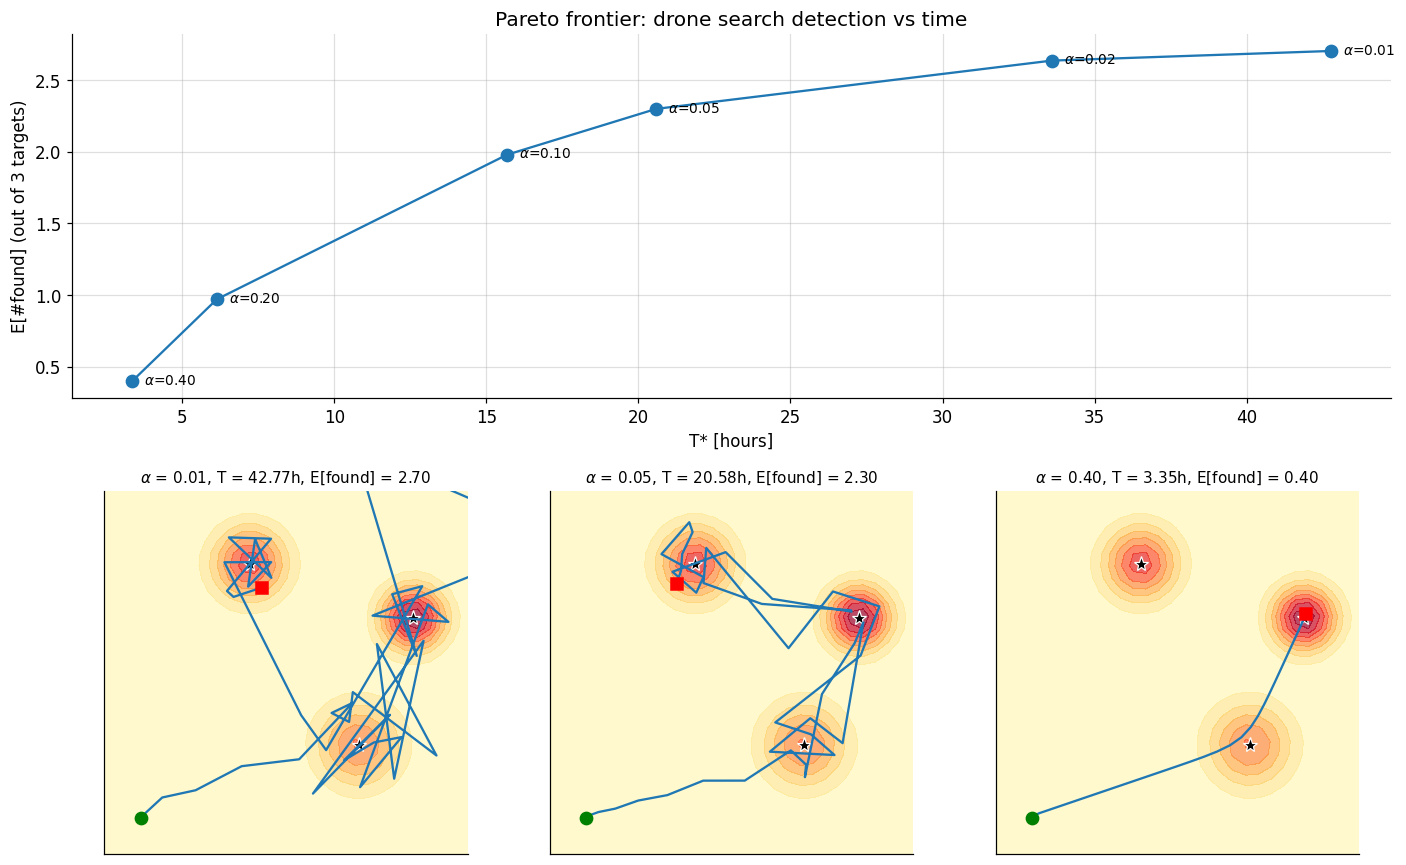

In [6]:
# Plot Pareto frontier and a few representative trajectories
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3)
ax_pareto = fig.add_subplot(gs[0, :])

# Sort pareto points by T for clean plotting
pareto_sorted = sorted(pareto, key=lambda p: p["T"])
T_arr      = np.array([p["T"]      for p in pareto_sorted])
P_arr      = np.array([p["Pfound"] for p in pareto_sorted])
alpha_arr  = np.array([p["alpha"]  for p in pareto_sorted])

ax_pareto.plot(T_arr, P_arr, "o-", ms=8, lw=1.5)
for T, P, a in zip(T_arr, P_arr, alpha_arr):
    ax_pareto.annotate(rf"$\alpha$={a:.2f}",
                       (T, P), xytext=(8, -2), textcoords="offset points", fontsize=9)
ax_pareto.set_xlabel("T* [hours]")
ax_pareto.set_ylabel("E[#found] (out of 3 targets)")
ax_pareto.set_title("Pareto frontier: drone search detection vs time")
ax_pareto.grid(True, alpha=0.4)

# Three representative trajectories from the Pareto set
# Pick low-alpha (long T), middle, high-alpha (short T)
representative = [pareto_sorted[-1], pareto_sorted[len(pareto_sorted) // 2], pareto_sorted[0]]

for ax_idx, p in enumerate(representative):
    ax = fig.add_subplot(gs[1, ax_idx])
    n_st = N_d + 1
    xt = p["z"][:n_st]; yt = p["z"][n_st:2 * n_st]
    levels = np.linspace(0, F_grid.max(), 10)
    ax.contourf(SX, SY, F_grid, levels=levels, cmap="YlOrRd", alpha=0.7)
    for t in targets:
        ax.plot(*t["mu"], "k*", ms=10, mec="white", mew=0.8)
    ax.plot(xt, yt, "-", color="C0", lw=1.5)
    ax.plot(xt[0], yt[0], "go", ms=8)
    ax.plot(xt[-1], yt[-1], "rs", ms=8)
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect("equal")
    ax.set_title(rf"$\alpha$ = {p['alpha']:.2f}, T = {p['T']:.2f}h, "
                 rf"E[found] = {p['Pfound']:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

**The Pareto frontier is the upper envelope of achievable $(T, \mathbb{E}[\#\mathrm{found}])$
combinations under Dubins kinematics.** Every point on the frontier is the best detection
achievable in the given time. The frontier's properties:

* **Monotone increasing**: more time always allows at least as much detection (you can always
  ignore the extra time).
* **Concave**: diminishing returns. The first hour over a high-prior mode buys a lot of
  $P_\mathrm{detect}$; the tenth hour over the same mode buys very little (you've already
  detected if it was going to detect).
* **Slope = $\alpha$ at each point**: this is what KKT stationarity in the weighted-sum
  formulation is guaranteeing. The optimizer chose $T^*$ such that one extra hour buys exactly
  $\alpha$ extra expected detections — any less and the time penalty wins, any more and the
  optimizer would have taken it.

### How the trajectory shape changes along the frontier

Looking at the three sample trajectories:

* **High $\alpha$** (short $T$): drone takes the shortest Dubins-feasible route through the
  modes, no loiter. Each pass is a fly-by giving moderate exposure.
* **Medium $\alpha$**: drone adds one loiter loop over the most promising target (highest
  prior peak), straight-flies the others.
* **Low $\alpha$**: drone adds loiter loops over multiple targets. The loiter circles are
  visible as small near-circular features in the trajectory.

This is the same **bang-bang structure** Pontryagin's principle predicts for time-bounded
Dubins problems: zero turning during transit (free arcs), $\pm\omega_\mathrm{max}$ during
loiter (saturated). Our pseudospectral discretization recovers this without explicit knowledge
of the bang-bang structure — KKT activity at the turning-rate inequality bound is what
SLSQP discovers.

## 5. The throughline

What changed from Part IX:

| Aspect | Part IX | Part X |
|---|---|---|
| Speed | $|\mathbf v| \le v_\mathrm{max}$ (inequality) | $|\mathbf v| = V$ (equality) |
| Heading | Implicit (from velocity direction) | Explicit decision variable $\theta_i$ |
| Turning | Unconstrained | $|\dot\theta| \le \omega_\mathrm{max}$ (inequality) |
| Decision vars | $2(N+1) + 1$ | $3(N+1) + 1$ |
| Cost | $-\mathbb{E}[\#\mathrm{found}]$ alone | $-\mathbb{E}[\#\mathrm{found}] + \alpha T$ |
| Output | Single trajectory | Pareto frontier |

The mathematical machinery is identical: pseudospectral collocation, adjoint-style gradient,
SLSQP with KKT inequality handling. Adding Dubins kinematics is just *more constraints in the
same NLP*, and the multi-objective sweep is *running the same NLP repeatedly with one
parameter changed*.

### What real systems do

* **Real fixed-wing drones** (aerospace, military, search-and-rescue) typically run a
  **receding-horizon controller** that solves a problem like this on each MPC step (every
  few seconds), executes the first segment, and replans with updated information. The
  optimization horizon is short (10–60 seconds) so the NLP is small and fast; the
  discretization is similar to ours but typically with finer time resolution.
* **Cooperative search** with multiple drones extends naturally: one $\mathbb{E}[\#\mathrm{found}]$
  functional, multiple Dubins trajectories with non-collision inequalities. The dimensionality
  grows linearly with the number of drones.
* **Adaptive (Bayesian) replanning** uses negative-information updates: if the drone has
  flown over a region and not detected, the posterior is reweighted (lower in that region),
  and the next replan cycles uses the updated prior. This is **continuous-time Bayesian
  search** / **POMDP-in-the-large**; modern formulations (Patten et al., Atanasov et al.)
  do exactly this with NMPC + adjoint-based gradient methods at $\sim 1$–$10$ Hz.

### Where this fits in the toolkit

After all ten parts:

| Part | Topic | Key tool |
|---|---|---|
| I–III | Forward problems, time stepping, unbounded domains | Differentiation matrices, ETDRK4, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI–VII | Optimal control, KKT, path constraints | LGL transcription, SLSQP, complementary slackness |
| VIII | Topology optimization | SIMP + adjoint sensitivity + OC + filter |
| IX | Drone search (kinematic) | Bayesian search functional + LGL |
| **X** | **Dubins drone search, multi-objective** | **Bang-bang turning + Pareto sweep** |

The throughline closes: **direct-collocation pseudospectral OC** + **adjoint-style gradients** +
**KKT inequalities** + **multi-objective Pareto sweeps** is the same machinery that NASA uses
for trajectory design, that Boeing uses for flight-control synthesis, and that
search-and-rescue agencies use for drone-team mission planning. The math is the math.